# 01 — Data Exploration
**Goal:** Load the telemetry we pulled in `fetch_telemetry.py`, understand its structure, and plot raw signals for one lap per driver side-by-side.

By the end of this notebook you should be able to *visually* see differences in how VER, HAM, and ALO drive.

In [1]:
import os
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Load config from project root
with open('../config.yaml') as f:
    config = yaml.safe_load(f)

DRIVERS = config['drivers']
RACE_TAG = f"{config['session']['year']}_{config['session']['race'].lower()}"
PROCESSED_DIR = os.path.join('..', config['data']['processed_dir'], RACE_TAG)

print('Drivers:', DRIVERS)
print('Looking in:', PROCESSED_DIR)

Drivers: ['VER', 'HAM', 'ALO']
Looking in: ../data/processed/2023_bahrain


## 1. Load parquet files

In [2]:
dfs = {}
for driver in DRIVERS:
    path = os.path.join(PROCESSED_DIR, f'{driver}.parquet')
    dfs[driver] = pd.read_parquet(path)
    print(f'{driver}: {dfs[driver].shape} — columns: {list(dfs[driver].columns)}')

VER: (39016, 9) — columns: ['Brake', 'Throttle', 'Speed', 'nGear', 'RPM', 'SessionTime', 'LapNumber', 'Driver', 'LapTime_s']
HAM: (39346, 9) — columns: ['Brake', 'Throttle', 'Speed', 'nGear', 'RPM', 'SessionTime', 'LapNumber', 'Driver', 'LapTime_s']
ALO: (39276, 9) — columns: ['Brake', 'Throttle', 'Speed', 'nGear', 'RPM', 'SessionTime', 'LapNumber', 'Driver', 'LapTime_s']


## 2. Inspect one driver's data

In [3]:
# Look at VER's data
dfs['VER'].head(10)

,Brake,Throttle,Speed,nGear,RPM,SessionTime,LapNumber,Driver,LapTime_s
0,False,16.0,0.000000,1,10076.374938,0 days 01:02:36.652000,1.0,VER,99.019
1,False,16.0,0.000000,1,10130.000000,0 days 01:02:36.762000,1.0,VER,99.019
2,False,16.0,0.000000,1,9993.499884,0 days 01:02:36.837000,1.0,VER,99.019
3,False,16.0,0.000000,1,9766.000000,0 days 01:02:36.962000,1.0,VER,99.019
4,False,16.0,0.964284,1,8956.001152,0 days 01:02:37.097000,1.0,VER,99.019
5,False,16.0,1.678572,1,8355.999616,0 days 01:02:37.197000,1.0,VER,99.019
6,False,16.0,2.000000,1,8086.000000,0 days 01:02:37.242000,1.0,VER,99.019
7,False,16.0,8.766662,1,6868.000896,0 days 01:02:37.416000,1.0,VER,99.019
8,False,16.0,16.000000,1,5566.000000,0 days 01:02:37.602000,1.0,VER,99.019
9,False,16.0,21.799996,1,4773.575583,0 days 01:02:37.776000,1.0,VER,99.019


In [4]:
# How many laps per driver?
for driver in DRIVERS:
    n_laps = dfs[driver]['LapNumber'].nunique()
    print(f'{driver}: {n_laps} laps')

VER: 53 laps
HAM: 53 laps
ALO: 53 laps


## 3. Plot raw telemetry for one lap — side by side

We pick lap 10 for all three drivers and plot Throttle, Brake, Speed, and Gear.
This is the first visual check: can you *see* stylistic differences?

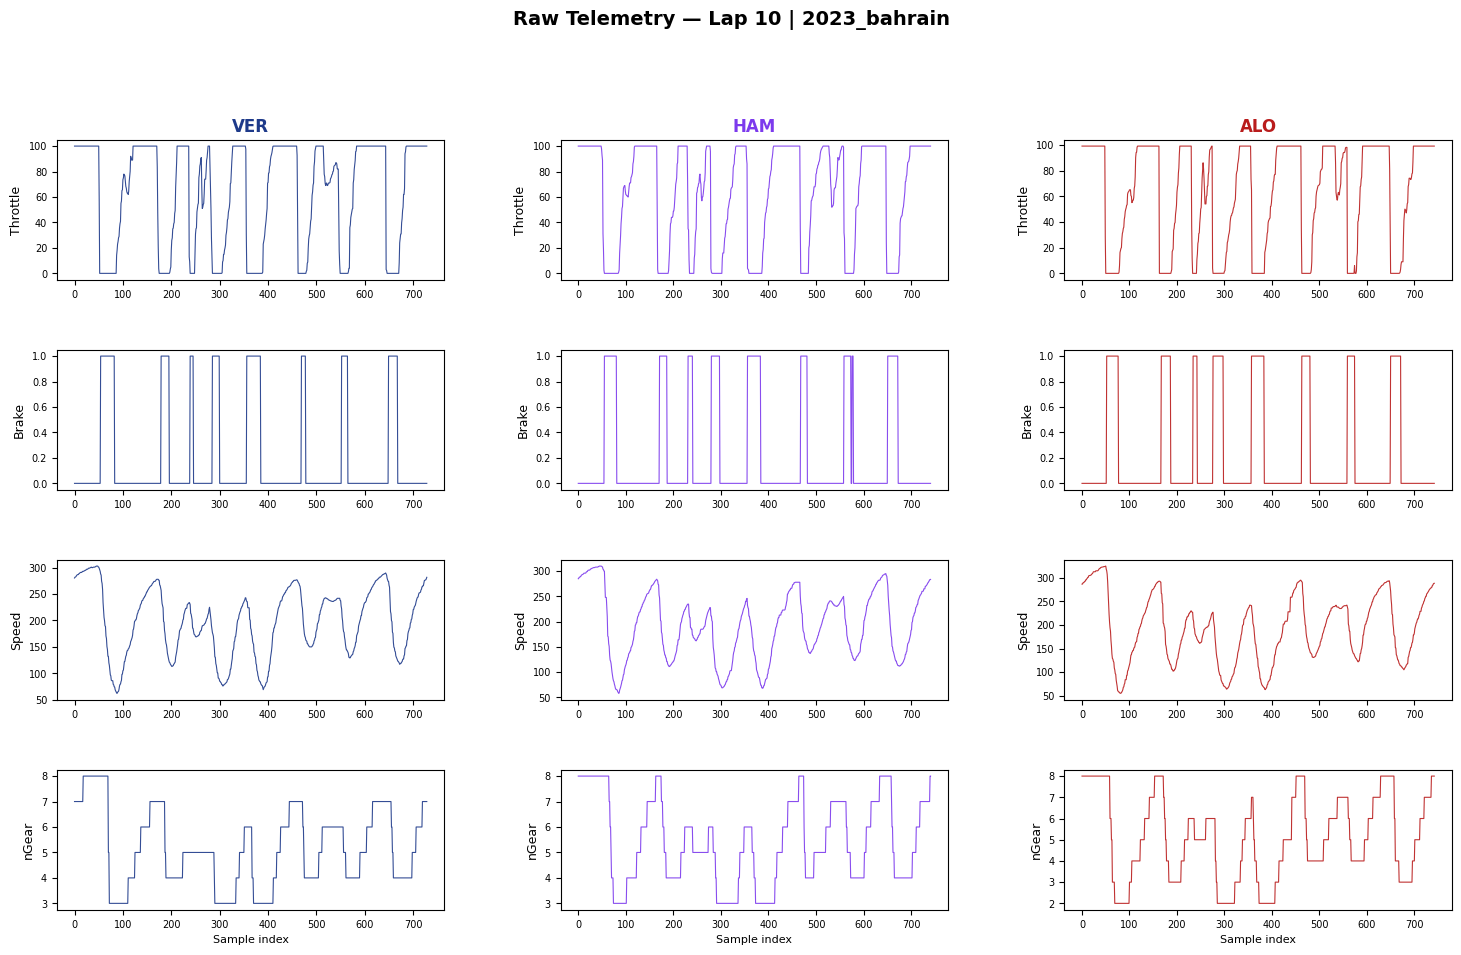

Saved to outputs/figures/01_raw_telemetry_lap10.png


In [5]:
LAP_TO_PLOT = 10
CHANNELS = ['Throttle', 'Brake', 'Speed', 'nGear']
COLORS = {'VER': '#1E3A8A', 'HAM': '#7C3AED', 'ALO': '#B91C1C'}

fig = plt.figure(figsize=(18, 10))
fig.suptitle(f'Raw Telemetry — Lap {LAP_TO_PLOT} | {RACE_TAG}', fontsize=14, fontweight='bold', y=1.01)

gs = gridspec.GridSpec(len(CHANNELS), len(DRIVERS), figure=fig, hspace=0.5, wspace=0.3)

for col_idx, driver in enumerate(DRIVERS):
    df_lap = dfs[driver][dfs[driver]['LapNumber'] == LAP_TO_PLOT].reset_index(drop=True)

    if df_lap.empty:
        print(f'[warn] No data for {driver} lap {LAP_TO_PLOT}')
        continue

    x = np.arange(len(df_lap))  # sample index as x-axis

    for row_idx, channel in enumerate(CHANNELS):
        ax = fig.add_subplot(gs[row_idx, col_idx])

        if channel not in df_lap.columns:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center', transform=ax.transAxes)
            continue

        ax.plot(x, df_lap[channel], color=COLORS[driver], linewidth=0.8, alpha=0.9)
        ax.set_ylabel(channel, fontsize=9)
        ax.tick_params(labelsize=7)

        if row_idx == 0:
            ax.set_title(driver, fontsize=12, fontweight='bold', color=COLORS[driver])
        if row_idx == len(CHANNELS) - 1:
            ax.set_xlabel('Sample index', fontsize=8)

os.makedirs('../outputs/figures', exist_ok=True)
plt.savefig('../outputs/figures/01_raw_telemetry_lap10.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to outputs/figures/01_raw_telemetry_lap10.png')

## 4. Distribution of lap times per driver

Quick sanity check — do lap time distributions look reasonable?

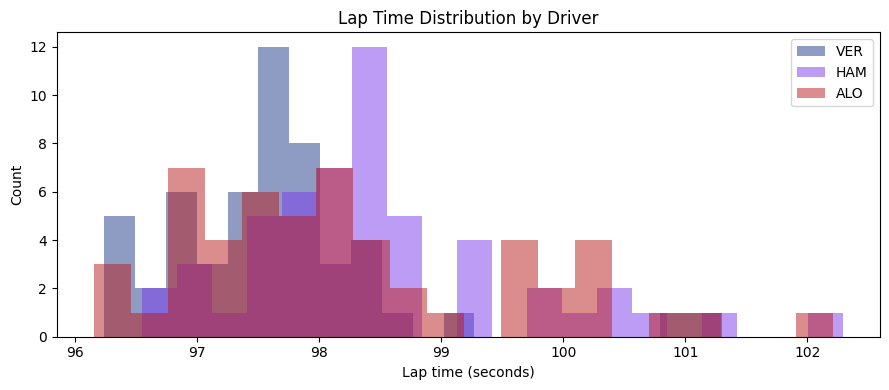

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))

for driver in DRIVERS:
    lap_times = (
        dfs[driver]
        .drop_duplicates('LapNumber')[['LapNumber', 'LapTime_s']]
        .dropna()
    )
    ax.hist(lap_times['LapTime_s'], bins=20, alpha=0.5, label=driver, color=COLORS[driver])

ax.set_xlabel('Lap time (seconds)')
ax.set_ylabel('Count')
ax.set_title('Lap Time Distribution by Driver')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/01_laptimes_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Throttle vs Brake scatter — first style signal

If drivers have distinct styles, their throttle/brake usage patterns should cluster differently.
This is a very rough preview of what the embedding model will do more rigorously.

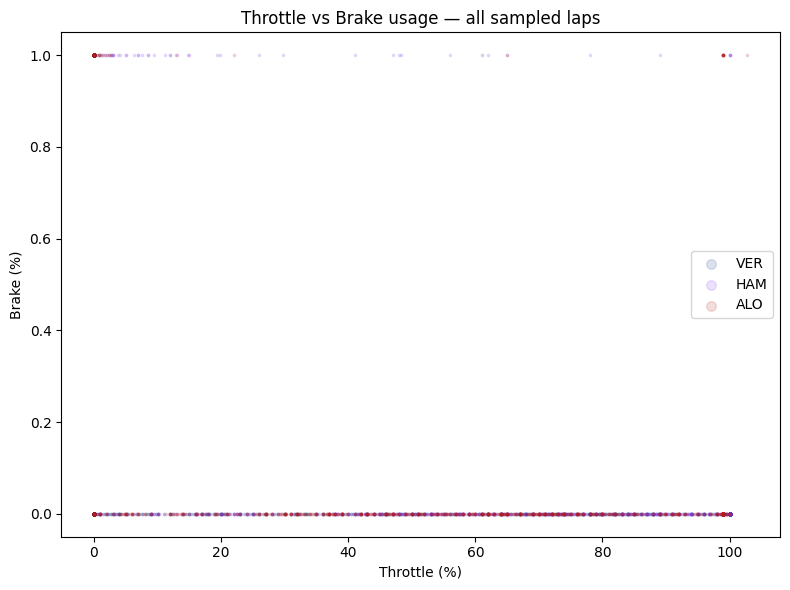

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

for driver in DRIVERS:
    # Sample 2000 rows to keep plot readable
    sample = dfs[driver][['Throttle', 'Brake']].dropna().sample(min(2000, len(dfs[driver])), random_state=42)
    ax.scatter(sample['Throttle'], sample['Brake'], alpha=0.15, s=3, label=driver, color=COLORS[driver])

ax.set_xlabel('Throttle (%)')
ax.set_ylabel('Brake (%)')
ax.set_title('Throttle vs Brake usage — all sampled laps')
ax.legend(markerscale=4)
plt.tight_layout()
plt.savefig('../outputs/figures/01_throttle_brake_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Milestone 1 complete ✓

You now have:
- Raw telemetry pulled and saved as parquet
- A working exploration notebook
- First visual evidence that telemetry differs between drivers

**Next:** `02_feature_engineering.ipynb` — convert raw time-series into per-lap summary features.